# Lab 8 – Task B: Drift

**4-phase state machine on Arduino:**
- Phase 0 APPROACH: full-speed forward + KF distance tracking
- Phase 1 ROTATE: once `TRIGGER_DIST` is reached, immediately switch to orient-PID and turn 180°
- Phase 2 RETURN: forward drive with IMU heading hold toward the 180° target
- Phase 3 DONE: stopped

## 1 – Imports & BLE setup

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import importlib

from ble import get_ble_controller
from base_ble import LOG
import cmd_types
importlib.reload(cmd_types)
from cmd_types import CMD

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['font.size'] = 12

print('Imports done.')

Imports done.


In [2]:
ble = get_ble_controller()
ble.connect()
print('Connected!')

def ble_reconnect():
    global ble
    print('Reconnecting BLE ...')
    try:
        ble.disconnect()
    except Exception:
        pass
    time.sleep(1.0)
    ble = get_ble_controller()
    ble.connect()
    print('Reconnected!')

2026-04-07 22:31:09,278 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:81:31:25:23:64
2026-04-07 22:31:09,279 | INFO     |: Scanning for device with address: c0:81:31:25:23:64, service UUID: d1e59283-ea64-46d2-9619-feda9179e362
2026-04-07 22:31:19,393 | INFO     |: Found 1 device(s) advertising service d1e59283-ea64-46d2-9619-feda9179e362
2026-04-07 22:31:19,394 | INFO     |: Selecting device: CA4CC09F-B046-D9C9-C03F-F04C7AD18338 (name: Artemis BLE)
2026-04-07 22:31:20,202 | INFO     |: Connected to c0:81:31:25:23:64
Connected!


## 2 – Parameters

Tune these before each run.

In [3]:
# ── Drift motion ──────────────────────────────────────────────────────────
APPROACH_PWM   = 160      # PWM during approach (0-255)
RETURN_PWM     = 160      # forward PWM during return
TRIGGER_DIST   = 914      # mm — 3 ft trigger for phase 0→1 rotate handoff
STOP_DIST      = 300      # mm — legacy field kept only for BLE command compatibility
RETURN_MS      = 2500     # ms — how long to drive back after rotation
TIMEOUT_MS     = 10000    # ms — global safety timeout
RETURN_YAW_KP  = 1.0      # heading-hold proportional gain during return

# ── Kalman Filter (from Lab 7 system ID) ─────────────────────────────────
KF_D   = 0.0003163
KF_M   = 0.0002093
KF_S1  = 50.0
KF_S2  = 50.0
KF_S3  = 20.0

# ── Legacy stop PID fields (unused in direct-turn drift mode) ─────────────
STOP_KP = 0.025
STOP_KI = 0.001
STOP_KD = 0.008

# ── Orientation PID (from Lab 6) ──────────────────────────────────────────
ORIENT_KP = 2.5
ORIENT_KI = 0.0
ORIENT_KD = 0.05

print('Parameters set.')

Parameters set.


## 3 – Configure robot

In [4]:
# KF parameters (step_pwm = APPROACH_PWM for normalization base)
ble.send_command(CMD.SET_KF_PARAMS,
    f"{KF_D}|{KF_M}|{KF_S1}|{KF_S2}|{KF_S3}|{APPROACH_PWM}")
time.sleep(0.15)
print('KF:', ble.receive_string(ble.uuid['RX_STRING']))

# Legacy stop PID gains are still sent for command compatibility, but direct-turn
# drift mode does not use the distance stop controller.
ble.send_command(CMD.SET_PID_GAINS,
    f"{STOP_KP}|{STOP_KI}|{STOP_KD}|{STOP_DIST}")
time.sleep(0.15)
print('Stop PID:', ble.receive_string(ble.uuid['RX_STRING']))

# Orientation PID gains
ble.send_command(CMD.SET_ORIENT_GAINS,
    f"{ORIENT_KP}|{ORIENT_KI}|{ORIENT_KD}")
time.sleep(0.15)
print('Orient gains:', ble.receive_string(ble.uuid['RX_STRING']))

# Pre-set all drift parameters without starting
# Format: approach_pwm|return_pwm|trigger_dist|stop_dist|return_ms|timeout_ms|return_yaw_kp
ble.send_command(CMD.SET_DRIFT_PARAMS,
    f"{APPROACH_PWM}|{RETURN_PWM}|{TRIGGER_DIST}|{STOP_DIST}|{RETURN_MS}|{TIMEOUT_MS}|{RETURN_YAW_KP}")
time.sleep(0.15)
print('Drift params:', ble.receive_string(ble.uuid['RX_STRING']))

KF: KF_PARAMS|d=%.7f|m=%.7f|s1=%.1f|s2=%.1f|s3=%.1f|step_pwm=1929379840
Stop PID: PID_GAINS|0.025|0.001|0.008|300
Orient gains: ORIENT_GAINS|2.500|0.000|0.050
Drift params: DRIFT_PARAMS|ap=160|rp=160|trigger=%.0f|stop=%.0f|ret=0|tout=0|ryk=%.2f


## 4 – Run drift

Position robot at starting line (≥ 4 m from wall), then execute the cell below.

In [5]:
raw_messages = []
_drift_done  = False

def drift_notify_handler(uuid, bytearray_data):
    global _drift_done
    try:
        msg = ble.bytearray_to_string(bytearray_data).strip()
        raw_messages.append(msg)
        if msg.startswith('DRF_END'):
            _drift_done = True
    except Exception as ex:
        print(f'Handler error: {ex}')

# ── Start run ────────────────────────────────────────────────────────────
raw_messages.clear()
_drift_done = False

try:
    ble.stop_notify(ble.uuid['RX_STRING'])
except Exception:
    pass
ble.start_notify(ble.uuid['RX_STRING'], drift_notify_handler)
time.sleep(0.05)

input('Place robot ≥4 m from wall. Press Enter to START ...')

# Format: approach_pwm|return_pwm|trigger_dist|stop_dist|return_ms|timeout_ms|return_yaw_kp
ble.send_command(CMD.DRIFT_START,
    f"{APPROACH_PWM}|{RETURN_PWM}|{TRIGGER_DIST}|{STOP_DIST}|{RETURN_MS}|{TIMEOUT_MS}|{RETURN_YAW_KP}")

print(f'Drift running ... waiting {TIMEOUT_MS/1000 + 1:.0f}s')
time.sleep(TIMEOUT_MS / 1000 + 1.5)

# Retrieve logged data
print('Fetching data ...')
_drift_done = False
ble.send_command(CMD.GET_DRIFT_DATA, '')

t0 = time.time()
while not _drift_done and (time.time() - t0 < 30.0):
    time.sleep(0.1)

ble.stop_notify(ble.uuid['RX_STRING'])
print(f'Received {len(raw_messages)} messages  (DRF_END: {_drift_done})')

Drift running ... waiting 11s
Fetching data ...
Received 425 messages  (DRF_END: True)


## 5 – Parse data

In [6]:
def wrap_deg(x):
    return ((x + 180.0) % 360.0) - 180.0

def parse_drift_row(s):
    """Parse 'DRF|raw|est|heading_x10|mot|phase|heading_err_x10|gyro_z_x10|ts' → dict."""
    parts = s.split('|')
    return {
        'raw_mm':  int(parts[1]),
        'est_mm':  int(parts[2]),
        'heading_deg': int(parts[3]) / 10.0,
        'motor':   int(parts[4]),
        'phase':   int(parts[5]),
        'heading_err_deg': int(parts[6]) / 10.0,
        'gyro_dps': int(parts[7]) / 10.0,
        'ts_ms':   int(parts[8]),
    }

drf_rows  = [parse_drift_row(m) for m in raw_messages if m.startswith('DRF|')]
ctrl_msgs = [m for m in raw_messages if not m.startswith('DRF|')]

df = pd.DataFrame(drf_rows)
if not df.empty:
    df['ts_ms'] -= df['ts_ms'].iloc[0]
    df['raw_valid'] = df['raw_mm'] > 0
    df['est_valid'] = df['est_mm'] > 0
    df['heading_abs_deg'] = df['heading_err_deg'].abs()
    df['gyro_abs_dps'] = df['gyro_dps'].abs()
    phase1_rows = df[df['phase'] == 1]
    if not phase1_rows.empty:
        approach_heading = phase1_rows['heading_deg'].iloc[0]
        df['turn_progress_deg'] = df['heading_deg'].apply(lambda x: abs(wrap_deg(x - approach_heading)))
    else:
        df['turn_progress_deg'] = float('nan')

print(f'Parsed {len(df)} data rows.')
print('Control messages:', ctrl_msgs)
df.head()

Parsed 422 data rows.
Control messages: ['DRIFT_START|ap=160|rp=160|trigger=%.0f|stop=%.0f|ret=0|tout=0|ryk=%.2f', 'DRIFT_DONE', 'DRF_END|422']


,raw_mm,est_mm,heading_deg,motor,phase,heading_err_deg,gyro_dps,ts_ms,raw_valid,est_valid,heading_abs_deg,gyro_abs_dps,turn_progress_deg
0,2282,2282,0.0,160,0,0.0,0.1,0,True,True,0.0,0.1,0.2
1,-1,2282,0.0,160,0,0.0,-0.1,15,False,True,0.0,0.1,0.2
2,-1,2282,0.0,160,0,0.0,-8.8,26,False,True,0.0,8.8,0.2
3,-1,2281,0.0,160,0,0.0,5.5,37,False,True,0.0,5.5,0.2
4,-1,2279,0.0,160,0,0.0,5.5,37,False,True,0.0,5.5,0.2


## 6 – Plot

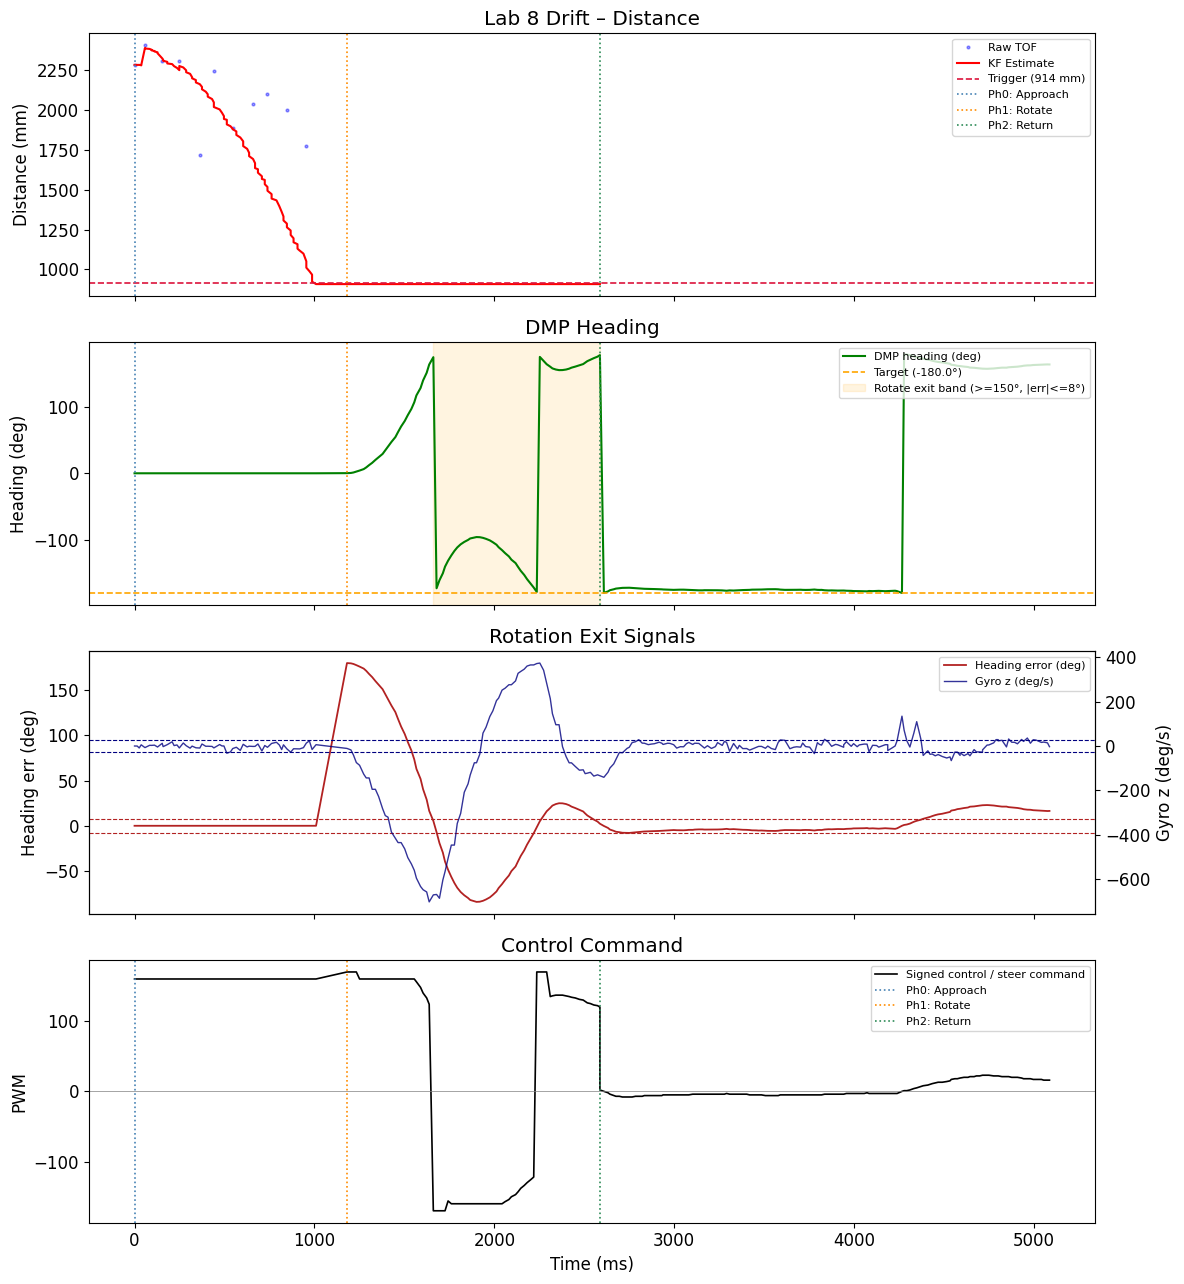

Saved lab8_drift.png


In [7]:
if df.empty:
    print('No data to plot.')
else:
    phase_colors = {0: 'steelblue', 1: 'darkorange', 2: 'seagreen'}
    phase_labels = {0: 'Approach', 1: 'Rotate', 2: 'Return'}

    phase_starts = {}
    for ph in [0, 1, 2]:
        rows = df[df['phase'] == ph]
        if not rows.empty:
            phase_starts[ph] = rows['ts_ms'].iloc[0]

    phase1 = df[df['phase'] == 1]
    phase2 = df[df['phase'] == 2]
    rotate_done_rows = phase1[(phase1['turn_progress_deg'] >= 150) & (phase1['heading_abs_deg'] <= 8)]

    heading_target = None
    if not phase1.empty:
        heading_target = wrap_deg(phase1['heading_deg'].iloc[0] + phase1['heading_err_deg'].iloc[0])

    fig, axes = plt.subplots(4, 1, figsize=(12, 13), sharex=True)

    ax = axes[0]
    raw = df[df['raw_valid']]
    est = df[df['est_valid']]
    ax.plot(raw['ts_ms'], raw['raw_mm'], 'b.', alpha=0.4, ms=4, label='Raw TOF')
    ax.plot(est['ts_ms'], est['est_mm'], 'r-', lw=1.5, label='KF Estimate')
    ax.axhline(TRIGGER_DIST, color='crimson', ls='--', lw=1.2, label=f'Trigger ({TRIGGER_DIST} mm)')
    for ph, t in phase_starts.items():
        ax.axvline(t, color=phase_colors[ph], ls=':', lw=1.2, label=f'Ph{ph}: {phase_labels[ph]}')
    ax.set_ylabel('Distance (mm)')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_title('Lab 8 Drift – Distance')

    ax = axes[1]
    ax.plot(df['ts_ms'], df['heading_deg'], 'g-', lw=1.5, label='DMP heading (deg)')
    if heading_target is not None:
        ax.axhline(heading_target, color='orange', ls='--', lw=1.2, label=f'Target ({heading_target:.1f}°)')
    if not rotate_done_rows.empty:
        ax.axvspan(rotate_done_rows['ts_ms'].iloc[0], rotate_done_rows['ts_ms'].iloc[-1],
                   color='orange', alpha=0.12, label='Rotate exit band (>=150°, |err|<=8°)')
    for ph, t in phase_starts.items():
        ax.axvline(t, color=phase_colors[ph], ls=':', lw=1.2)
    ax.set_ylabel('Heading (deg)')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_title('DMP Heading')

    ax = axes[2]
    ax.plot(df['ts_ms'], df['heading_err_deg'], color='firebrick', lw=1.3, label='Heading error (deg)')
    ax.axhline(8, color='firebrick', ls='--', lw=0.8)
    ax.axhline(-8, color='firebrick', ls='--', lw=0.8)
    ax2 = ax.twinx()
    ax2.plot(df['ts_ms'], df['gyro_dps'], color='navy', lw=1.0, alpha=0.8, label='Gyro z (deg/s)')
    ax2.axhline(25, color='navy', ls='--', lw=0.8)
    ax2.axhline(-25, color='navy', ls='--', lw=0.8)
    ax.set_ylabel('Heading err (deg)')
    ax2.set_ylabel('Gyro z (deg/s)')
    ax.set_title('Rotation Exit Signals')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

    ax = axes[3]
    ax.plot(df['ts_ms'], df['motor'], 'k-', lw=1.2, label='Signed control / steer command')
    ax.axhline(0, color='gray', ls='-', lw=0.5)
    for ph, t in phase_starts.items():
        ax.axvline(t, color=phase_colors[ph], ls=':', lw=1.2, label=f'Ph{ph}: {phase_labels[ph]}')
    ax.set_ylabel('PWM')
    ax.set_xlabel('Time (ms)')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_title('Control Command')

    plt.tight_layout()
    plt.savefig('lab8_drift.png', dpi=150)
    plt.show()
    print('Saved lab8_drift.png')

## 7 – Diagnostics

In [8]:
if not df.empty:
    total_ms  = df['ts_ms'].iloc[-1] - df['ts_ms'].iloc[0]
    ph_counts = df['phase'].value_counts().sort_index()
    print(f'Total run time  : {total_ms} ms')
    print(f'Rows per phase  : {ph_counts.to_dict()}')

    if 0 in ph_counts.index:
        approach = df[df['phase'] == 0]
        kf_at_trigger = approach['est_mm'].iloc[-1]
        print(f'\n[Phase 0 → 1] KF dist at rotate trigger : {kf_at_trigger:.0f} mm  (target {TRIGGER_DIST} mm)')

    if 1 in ph_counts.index:
        rotate = df[df['phase'] == 1]
        heading_start = rotate['heading_deg'].iloc[0]
        heading_end = rotate['heading_deg'].iloc[-1]
        delta = wrap_deg(heading_end - heading_start)
        rotate_ms = rotate['ts_ms'].iloc[-1] - rotate['ts_ms'].iloc[0]
        final_err = rotate['heading_err_deg'].iloc[-1]
        final_gyro = rotate['gyro_dps'].iloc[-1]
        progress_rows = rotate[rotate['turn_progress_deg'] >= 150]
        done_like = rotate[(rotate['turn_progress_deg'] >= 150) & (rotate['heading_abs_deg'] <= 8)]
        print(f'[Phase 1] Heading: {heading_start:.1f}° → {heading_end:.1f}°  (delta {delta:.1f}°)')
        print(f'[Phase 1] Rotation duration : {rotate_ms} ms')
        print(f'[Phase 1] Final heading err : {final_err:+.1f}°')
        print(f'[Phase 1] Final gyro z      : {final_gyro:+.1f}°/s')
        if not progress_rows.empty and not done_like.empty:
            fine_tune_ms = done_like['ts_ms'].iloc[0] - progress_rows['ts_ms'].iloc[0]
            print(f'[Phase 1] 150°→exit-band time : {fine_tune_ms} ms')
        print(f'[Phase 1] Exit-band rows    : {len(done_like)}')

    if 2 in ph_counts.index:
        ret = df[df['phase'] == 2]
        print(f'[Phase 2] Max |heading err| : {ret["heading_abs_deg"].max():.1f}°')
        print(f'[Phase 2] Mean |heading err|: {ret["heading_abs_deg"].mean():.1f}°')

Total run time  : 5086 ms
Rows per phase  : {0: 104, 1: 81, 2: 237}

[Phase 0 → 1] KF dist at rotate trigger : 908 mm  (target 914 mm)
[Phase 1] Heading: 0.2° → 177.7°  (delta 177.5°)
[Phase 1] Rotation duration : 1406 ms
[Phase 1] Final heading err : +2.3°
[Phase 1] Final gyro z      : -133.8°/s
[Phase 1] 150°→exit-band time : 37 ms
[Phase 1] Exit-band rows    : 7
[Phase 2] Max |heading err| : 22.9°
[Phase 2] Mean |heading err|: 8.2°


## 8 – Emergency stop

In [9]:
ble.send_command(CMD.DRIFT_STOP, '')
time.sleep(0.1)
print('Emergency stop sent.')

Emergency stop sent.


## 9 – Tuning notes

| Issue | Suggested fix |
|-------|---------------|
| Starts the turn too late | Increase `TRIGGER_DIST` |
| Starts the turn too early | Decrease `TRIGGER_DIST` |
| Exits rotation too early | Increase `ORIENT_KD` or reduce `TURN_PWM_MAX` |
| Undershoots 180° | Increase `ORIENT_KP` |
| Overshoots or oscillates near 180° | Decrease `ORIENT_KP` or increase `ORIENT_KD` |
| Return leg drifts sideways | Increase `RETURN_YAW_KP` |
| Doesn't return past start line | Increase `RETURN_MS` or `RETURN_PWM` |
| KF trigger looks wrong | Re-run Lab 7 system ID at the same `APPROACH_PWM` |

In [10]:
ble.disconnect()